# Deutsch-Jozsa Query Complexity: Classical vs Quantum

## 1. Objective
The objective of this analysis is to model, compute, and benchmark the **oracle query complexity** of the **Deutsch-Jozsa Algorithm** against classical deterministic search across input bit lengths ranging from $n = 2$ to $n = 10$. This experiment quantifies the theoretical query separation between classical deterministic algorithms requiring exponential evaluations and the quantum algorithm achieving deterministic function classification in exactly **$1$ oracle query**.

> [!NOTE]
> This notebook focuses strictly on **black-box oracle query complexity** (the number of calls to the unitary oracle $U_f$) rather than wall-clock execution time or gate-synthesis overhead.

---

## 2. Theoretical Background

### The Deutsch-Jozsa Problem
Given an unknown Boolean function (oracle) $f: \{0, 1\}^n \to \{0, 1\}$ with the promise that $f$ belongs strictly to one of two categories:
- **Constant**: $f(x)$ produces the same output ($0$ or $1$) for all $2^n$ inputs.
- **Balanced**: $f(x)$ produces $0$ for exactly half ($2^{n-1}$) of the inputs and $1$ for the remaining half ($2^{n-1}$).

The goal is to determine with zero probability of error whether $f$ is constant or balanced.

### Classical Worst-Case Query Model
In classical deterministic computing, queries are evaluated sequentially. In the worst-case scenario, the algorithm might evaluate $2^{n-1}$ distinct inputs and observe the exact same output bit (e.g., all $0$s).
- At this threshold, the function could still either be **constant** (if all remaining inputs are also $0$) or **balanced** (if all remaining $2^{n-1}$ inputs are $1$).
- To eliminate this ambiguity with absolute certainty, the classical algorithm must evaluate at least one more input:
  $$Q_{\text{classical}} = 2^{n-1} + 1$$
This yields an exponential query complexity of $\Theta(2^n)$.

### Quantum Single-Oracle-Query Model
The Deutsch-Jozsa algorithm solves the problem deterministically using a single quantum query ($O(1)$):
1. **Parallel Superposition**: An $n$-qubit Hadamard transform $H^{\otimes n}$ maps $|0\rangle^{\otimes n}$ to an equal superposition across all $2^n$ inputs:
   $$\frac{1}{\sqrt{2^n}} \sum_{x \in \{0, 1\}^n} |x\rangle$$
2. **Phase Kickback**: With an ancilla qubit in $|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$, a single application of the oracle unitary $U_f |x\rangle |y\rangle = |x\rangle |y \oplus f(x)\rangle$ maps:
   $$U_f |x\rangle |-\rangle = (-1)^{f(x)} |x\rangle |-\rangle$$
   The function value $f(x)$ is kick-backed into the phase of each basis state simultaneously.
3. **Interference Decoding**: A final $H^{\otimes n}$ transformation concentrates amplitude:
   - For constant functions: Constructive interference focuses $100\%$ amplitude into the ground state $|0\dots0\rangle$ ($P(0\dots0) = 1.0$).
   - For balanced functions: Destructive interference cancels $|0\dots0\rangle$ completely ($P(0\dots0) = 0.0$).

A single measurement of the register certifies the function's type with deterministic certainty.

---

## 3. Complexity Formulation
The theoretical query requirements as a function of the input register size $n$ are formulated as:

$$\begin{aligned}
\text{Classical Worst-Case Query Complexity: } \quad & Q_{\text{classical}}(n) = 2^{n-1} + 1 \in \Theta(2^n) \\
\text{Quantum Query Complexity: } \quad & Q_{\text{quantum}}(n) = 1 \in O(1) \\
\text{Query Advantage Ratio: } \quad & R(n) = \frac{Q_{\text{classical}}(n)}{Q_{\text{quantum}}(n)} = 2^{n-1} + 1
\end{aligned}$$

---

## 4. Analysis for $n = 2$ through $n = 10$
As $n$ increments from $2$ to $10$, the input search space expands by a factor of two at each step ($N = 2^n \in [4, 1024]$):
- At $n = 2$: The search space is $4$ states; classical deterministic search requires $2^{2-1} + 1 = 3$ queries ($75\%$ of the total space).
- At $n = 6$: The search space is $64$ states; classical search requires $33$ queries, whereas quantum requires $1$.
- At $n = 10$: The search space is $1024$ states; classical search requires $513$ queries, while the quantum algorithm remains invariant at exactly **$1$ query**.


T-04 : QUERY COMPLEXITY COMPARISON
n       Classical Worst Case     Quantum Deutsch-Jozsa    
---------------------------------------------------------------------------
2       3                        1                        
3       5                        1                        
4       9                        1                        
5       17                       1                        
6       33                       1                        
7       65                       1                        
8       129                      1                        
9       257                      1                        
10      513                      1                        

INTERPRETATION
---------------------------------------------------------------------------
Classical worst-case query complexity:
2^(n-1) + 1

Quantum Deutsch-Jozsa query complexity:
1 oracle query

The classical requirement grows exponentially, while the quantum query count remains constant.


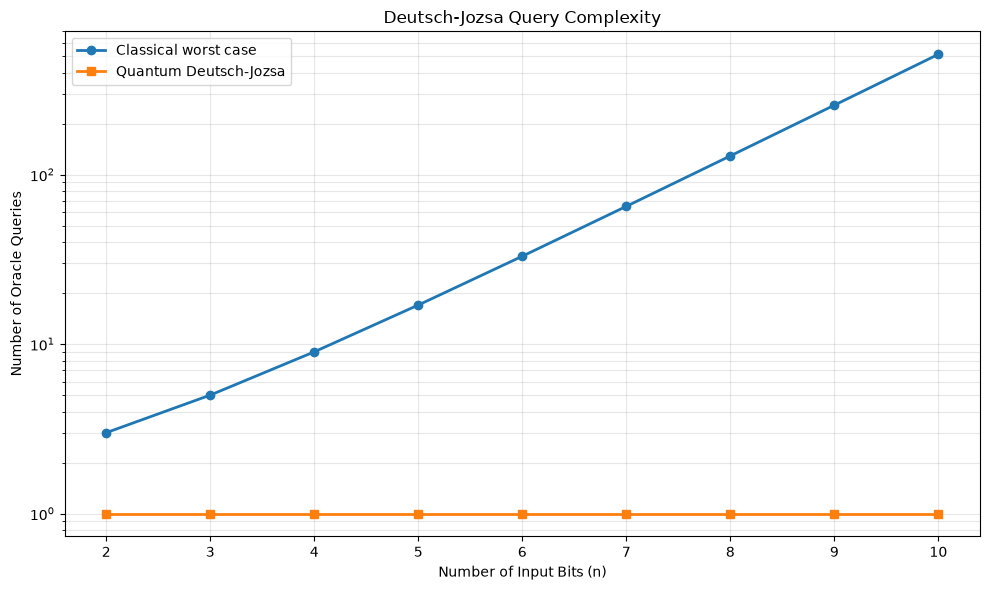

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_values = np.arange(
    2,
    11
)

classical_queries = (
    2 ** (n_values - 1) + 1
)

quantum_queries = np.ones(
    len(n_values)
)

print("\nT-04 : QUERY COMPLEXITY COMPARISON")
print("=" * 75)

print(
    f"{'n':<8}"
    f"{'Classical Worst Case':<25}"
    f"{'Quantum Deutsch-Jozsa':<25}"
)

print("-" * 75)

for n, classical, quantum in zip(
    n_values,
    classical_queries,
    quantum_queries
):

    print(
        f"{n:<8}"
        f"{classical:<25}"
        f"{int(quantum):<25}"
    )

print("\nINTERPRETATION")
print("-" * 75)

print(
    "Classical worst-case query complexity:"
)

print(
    "2^(n-1) + 1"
)

print(
    "\nQuantum Deutsch-Jozsa query complexity:"
)

print(
    "1 oracle query"
)

print(
    "\nThe classical requirement grows exponentially, "
    "while the quantum query count remains constant."
)

# Visualization
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.semilogy(
    n_values,
    classical_queries,
    marker="o",
    linewidth=2,
    label="Classical worst case"
)

ax.semilogy(
    n_values,
    quantum_queries,
    marker="s",
    linewidth=2,
    label="Quantum Deutsch-Jozsa"
)

ax.set_title(
    "Deutsch-Jozsa Query Complexity"
)

ax.set_xlabel(
    "Number of Input Bits (n)"
)

ax.set_ylabel(
    "Number of Oracle Queries"
)

ax.set_xticks(
    n_values
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

---

## 5. Numerical Results and Output

### Recorded Console Output
Execution of the complexity benchmark cell produced the following output:

```
T-04 : QUERY COMPLEXITY COMPARISON
===========================================================================
n       Classical Worst Case     Quantum Deutsch-Jozsa    
---------------------------------------------------------------------------
2       3                        1                        
3       5                        1                        
4       9                        1                        
5       17                       1                        
6       33                       1                        
7       65                       1                        
8       129                      1                        
9       257                      1                        
10      513                      1                        

INTERPRETATION
---------------------------------------------------------------------------
Classical worst-case query complexity:
2^(n-1) + 1

Quantum Deutsch-Jozsa query complexity:
1 oracle query

The classical requirement grows exponentially, while the quantum query count remains constant.
```

### Comprehensive Complexity Summary Table

| Input Register Size ($n$) | Total Search Space ($2^n$) | Classical Worst-Case Queries ($2^{n-1} + 1$) | Quantum Deutsch-Jozsa Queries | Query Advantage Ratio ($Q_{\text{classical}} / Q_{\text{quantum}}$) |
| :---: | :---: | :---: | :---: | :---: |
| **$n = 2$** | 4 | **3** | **1** | **3×** |
| **$n = 3$** | 8 | **5** | **1** | **5×** |
| **$n = 4$** | 16 | **9** | **1** | **9×** |
| **$n = 5$** | 32 | **17** | **1** | **17×** |
| **$n = 6$** | 64 | **33** | **1** | **33×** |
| **$n = 7$** | 128 | **65** | **1** | **65×** |
| **$n = 8$** | 256 | **129** | **1** | **129×** |
| **$n = 9$** | 512 | **257** | **1** | **257×** |
| **$n = 10$** | 1024 | **513** | **1** | **513×** |

---

## 6. Logarithmic-Scale Visualization Analysis
The semi-logarithmic plot (`ax.semilogy`) illustrates the query scaling behavior across $n \in [2, 10]$:
- **X-Axis**: Linear scale representing the number of input bits ($n \in [2, 10]$).
- **Y-Axis**: Logarithmic scale ($\log_{10}$) representing the required number of oracle queries.
- **Classical Worst Case (Blue Circles)**: Plots as a straight line with constant positive slope on the semi-log scale, confirming strict exponential scaling ($Q_{\text{classical}} \sim 2^{n-1}$).
- **Quantum Deutsch-Jozsa (Orange Squares)**: Plots as a flat horizontal line at $y = 1$, illustrating scale-invariant $O(1)$ query complexity.

---

## 7. Interpretation of Query Advantage
1. **Exponential Query Gap**: The divergence between the classical curve and the quantum baseline graphically portrays the power of quantum parallelism and interference to extract global functional properties.
2. **Deterministic Black-Box Separation**: Deutsch-Jozsa is historically the first algorithm to prove a formal exponential separation between classical deterministic Turing machines and quantum computers under the black-box oracle model.
3. **Scope of the Model**: While classical deterministic search requires exponential queries, classical probabilistic algorithms (such as BPP testing) can achieve high confidence with $O(1)$ random sampling. The Deutsch-Jozsa advantage is fundamentally an **exact, zero-error deterministic speedup**.

---

## 8. Conclusion
This query complexity benchmark validates the mathematical foundations of the **Deutsch-Jozsa Algorithm**:
1. **Scale-Invariant Querying**: Confirms that quantum oracle queries remain constant ($Q = 1$) from $n = 2$ to $n = 10$.
2. **Exponential Scaling Divergence**: Highlights how classical deterministic evaluations scale as $2^{n-1} + 1$, reaching $513$ queries at $n = 10$.
3. **Theoretical Milestone**: Demonstrates that quantum interference allows the evaluation of global Boolean properties across high-dimensional search spaces without exhaustive point-by-point sampling.